   Unnamed: 0        Date  Monthly Mean Total Sunspot Number
0           0  1749-01-31                               96.7
1           1  1749-02-28                              104.3
2           2  1749-03-31                              116.7
3           3  1749-04-30                               92.8
4           4  1749-05-31                              141.7
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3252 entries, 0 to 3251
Data columns (total 3 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         3252 non-null   int64  
 1   Date                               3252 non-null   object 
 2   Monthly Mean Total Sunspot Number  3252 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 76.3+ KB
None

Colunas:
Index(['Unnamed: 0', 'Date', 'Monthly Mean Total Sunspot Number'], dtype='object')


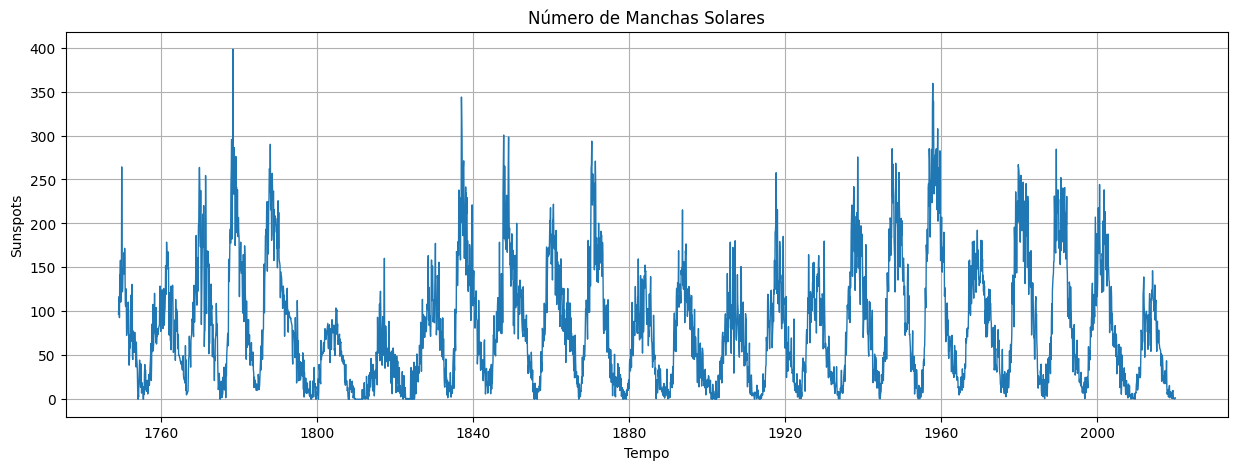

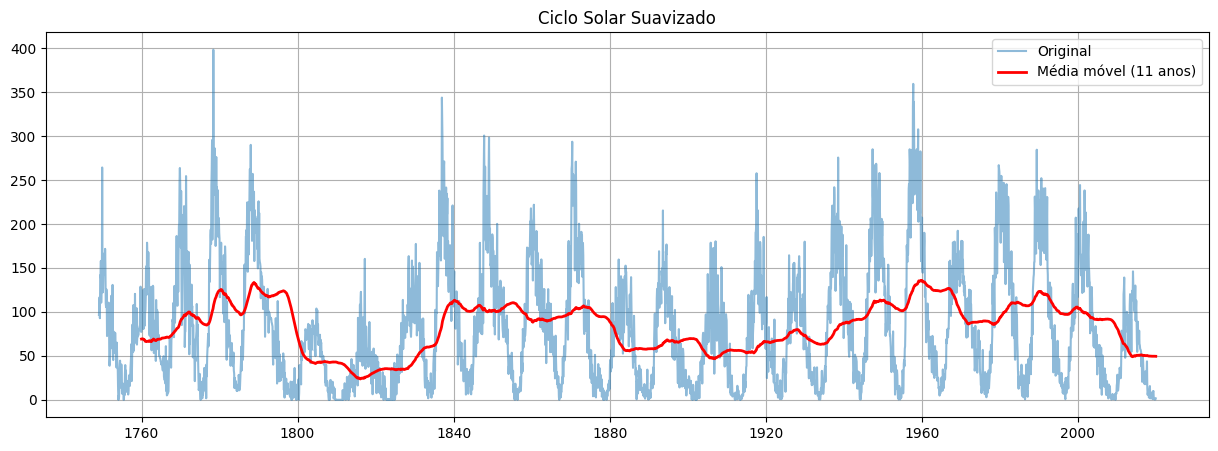

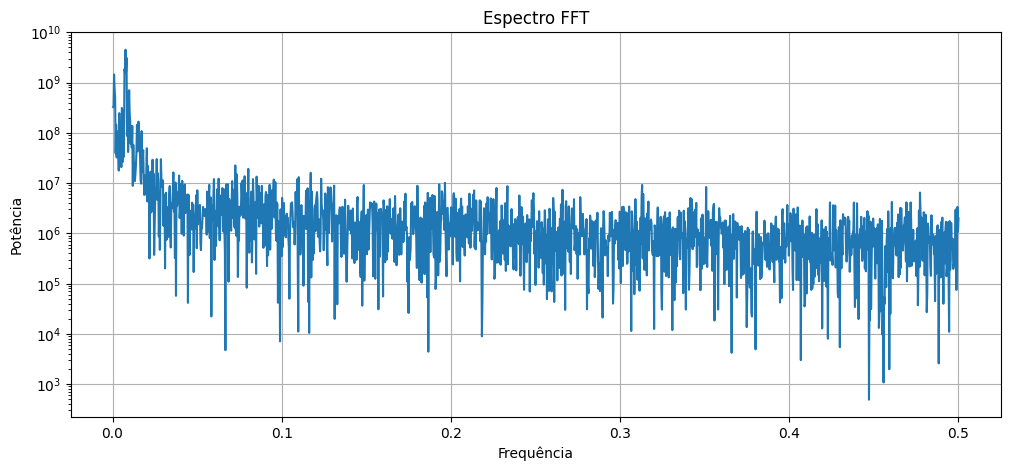


Período dominante = 130.08 unidades de tempo


In [ ]:
# ============================================================
# Série Temporal de Manchas Solares
# Google Colab
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Baixar dados diretamente do GitHub
# ------------------------------------------------------------

url = "https://raw.githubusercontent.com/ThinamXx/TimeSeries_Sunspots/master/sunspots.csv"

df = pd.read_csv(url)

print(df.head())
print(df.info())

# ------------------------------------------------------------
# Verificar nomes das colunas
# ------------------------------------------------------------

print("\nColunas:")
print(df.columns)

# ------------------------------------------------------------
# Criar eixo temporal
# ------------------------------------------------------------

# O dataset possui normalmente:
# Month, Sunspots

# Correcting column selection
time = pd.to_datetime(df.iloc[:, 1]) # 'Date' column converted to datetime
sunspots = df.iloc[:, 2]           # 'Monthly Mean Total Sunspot Number' column

# ------------------------------------------------------------
# Plot série temporal
# ------------------------------------------------------------

plt.figure(figsize=(15,5))
plt.plot(time, sunspots, lw=1)
plt.title("Número de Manchas Solares")
plt.xlabel("Tempo")
plt.ylabel("Sunspots")
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# Média móvel
# ------------------------------------------------------------

window = 132      # ~11 anos se mensal

moving_avg = pd.Series(sunspots).rolling(window).mean()

plt.figure(figsize=(15,5))
plt.plot(time, sunspots, alpha=0.5, label='Original')
plt.plot(time, moving_avg,
         color='red',
         linewidth=2,
         label='Média móvel (11 anos)')
plt.legend()
plt.grid(True)
plt.title("Ciclo Solar Suavizado")
plt.show()

# ------------------------------------------------------------
# FFT
# ------------------------------------------------------------

signal = sunspots - np.mean(sunspots)

fft_vals = np.fft.rfft(signal)
freqs = np.fft.rfftfreq(len(signal), d=1)

power = np.abs(fft_vals)**2

plt.figure(figsize=(12,5))
plt.plot(freqs[1:], power[1:])
plt.xlabel("Frequência")
plt.ylabel("Potência")
plt.title("Espectro FFT")
plt.yscale("log")
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# Período dominante
# ------------------------------------------------------------

peak = np.argmax(power[1:]) + 1

period = 1 / freqs[peak]

print(f"\nPeríodo dominante = {period:.2f} unidades de tempo")

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams['font.size'] = 16
plt.rcParams['axes.titlesize'] = 22
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['legend.fontsize'] = 16

Média = 82.07
Sigma = 67.85
3 Sigma = 203.56


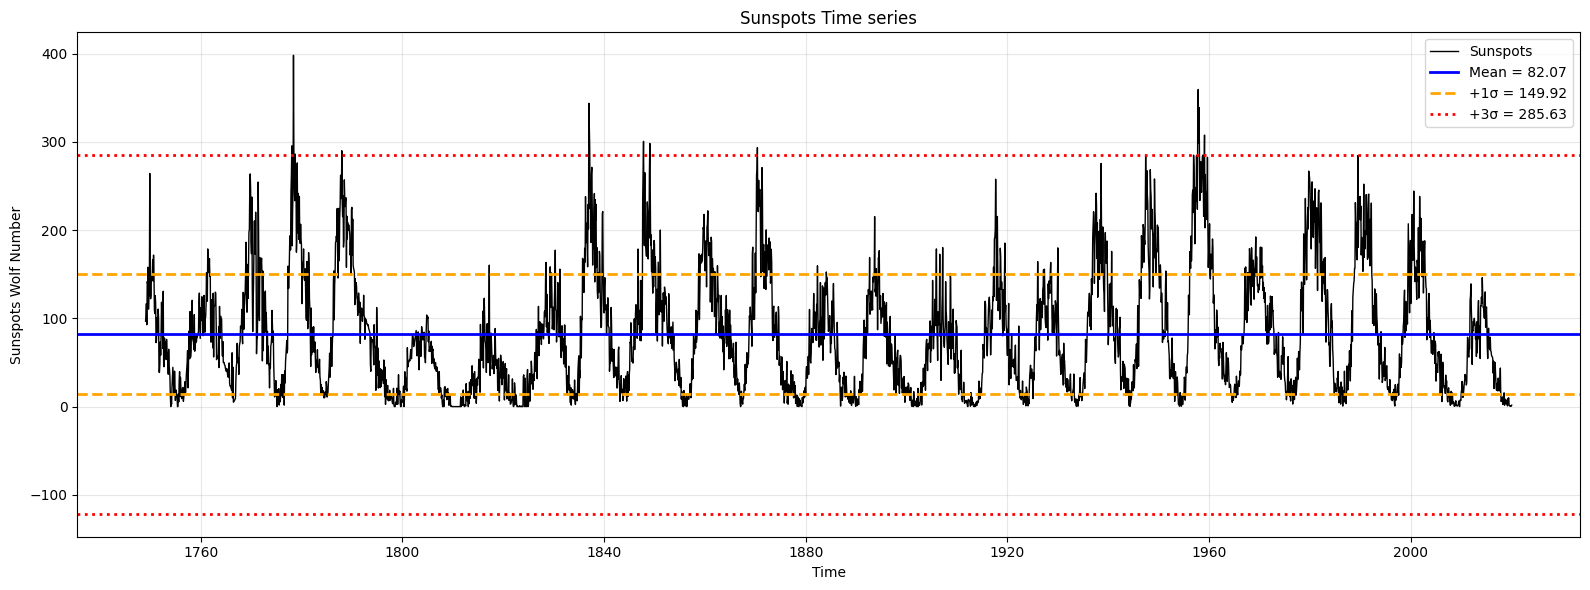

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Carregar dados
# ------------------------------------------------------------

url = "https://raw.githubusercontent.com/ThinamXx/TimeSeries_Sunspots/master/sunspots.csv"

df = pd.read_csv(url)

# Correcting column selection and type conversion
time = pd.to_datetime(df.iloc[:, 1]) # 'Date' column converted to datetime
sunspots = df.iloc[:, 2]           # 'Monthly Mean Total Sunspot Number' column

# ------------------------------------------------------------
# Estatísticas
# ------------------------------------------------------------

mean_value = np.mean(sunspots)
sigma = np.std(sunspots)

print(f"Média = {mean_value:.2f}")
print(f"Sigma = {sigma:.2f}")
print(f"3 Sigma = {3*sigma:.2f}")

# ------------------------------------------------------------
# Gráfico
# ------------------------------------------------------------

plt.figure(figsize=(16,6))

# Série temporal
plt.plot(time, sunspots,
         color='black',
         linewidth=1,
         label='Sunspots')

# Média
plt.axhline(mean_value,
            color='blue',
            linewidth=2,
            label=f'Mean = {mean_value:.2f}')

# +1 sigma
plt.axhline(mean_value + sigma,
            color='orange',
            linestyle='--',
            linewidth=2,
            label=f'+1σ = {mean_value + sigma:.2f}')

# -1 sigma
plt.axhline(mean_value - sigma,
            color='orange',
            linestyle='--',
            linewidth=2)

# +3 sigma
plt.axhline(mean_value + 3*sigma,
            color='red',
            linestyle=':',
            linewidth=2,
            label=f'+3σ = {mean_value + 3*sigma:.2f}')

# -3 sigma
plt.axhline(mean_value - 3*sigma,
            color='red',
            linestyle=':',
            linewidth=2)

plt.title('Sunspots Time series')
plt.xlabel('Time')
plt.ylabel('Sunspots Wolf Number')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

Statistical Moments
Mean                 = 82.0707
Variance             = 4604.2062
Standard Deviation   = 67.8543
Central Moment μ2    = 4604.2062
Central Moment μ3    = 288301.0064
Central Moment μ4    = 70649616.8115
Skewness             = 0.9228
Excess Kurtosis      = 0.3327


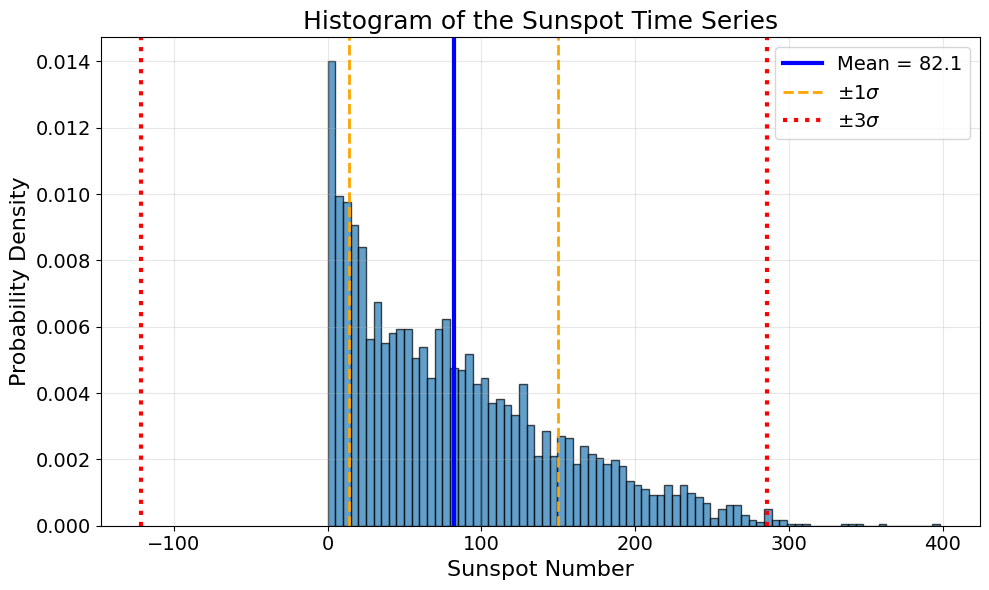

In [ ]:
# ============================================================
# Histogram and Statistical Moments
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

# Convert to NumPy array
x = np.array(sunspots)

# ------------------------------------------------------------
# Basic Statistics
# ------------------------------------------------------------

mean = np.mean(x)
variance = np.var(x)
std = np.std(x)

# ------------------------------------------------------------
# Central Moments
# ------------------------------------------------------------

mu2 = np.mean((x - mean)**2)
mu3 = np.mean((x - mean)**3)
mu4 = np.mean((x - mean)**4)

# ------------------------------------------------------------
# Skewness and Kurtosis
# ------------------------------------------------------------

sk = skew(x)
ku = kurtosis(x, fisher=True)

print('================================')
print('Statistical Moments')
print('================================')

print(f'Mean                 = {mean:.4f}')
print(f'Variance             = {variance:.4f}')
print(f'Standard Deviation   = {std:.4f}')
print(f'Central Moment μ2    = {mu2:.4f}')
print(f'Central Moment μ3    = {mu3:.4f}')
print(f'Central Moment μ4    = {mu4:.4f}')
print(f'Skewness             = {sk:.4f}')
print(f'Excess Kurtosis      = {ku:.4f}')

# ------------------------------------------------------------
# Histogram
# ------------------------------------------------------------

plt.figure(figsize=(10,6))

plt.hist(x,
         bins=80,
         density=True,
         alpha=0.7,
         edgecolor='black')

# Mean
plt.axvline(mean,
            color='blue',
            linewidth=3,
            label=f'Mean = {mean:.1f}')

# ±1 sigma
plt.axvline(mean + std,
            color='orange',
            linestyle='--',
            linewidth=2,
            label=r'$\pm1\sigma$')

plt.axvline(mean - std,
            color='orange',
            linestyle='--',
            linewidth=2)

# ±3 sigma
plt.axvline(mean + 3*std,
            color='red',
            linestyle=':',
            linewidth=3,
            label=r'$\pm3\sigma$')

plt.axvline(mean - 3*std,
            color='red',
            linestyle=':',
            linewidth=3)

plt.xlabel('Sunspot Number', fontsize=16)
plt.ylabel('Probability Density', fontsize=16)
plt.title('Histogram of the Sunspot Time Series', fontsize=18)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend(fontsize=14)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import normaltest

statistic, pvalue = normaltest(x)

print('\nNormality Test (D’Agostino-Pearson)')
print('-----------------------------------')
print(f'Test Statistic = {statistic:.4f}')
print(f'p-value        = {pvalue:.4e}')

if pvalue < 0.05:
    print('Result: Reject the null hypothesis of normality.')
else:
    print('Result: Cannot reject the null hypothesis of normality.')


Normality Test (D’Agostino-Pearson)
-----------------------------------
Test Statistic = 354.0746
p-value        = 1.2992e-77
Result: Reject the null hypothesis of normality.


Cullen-Frey Coordinates
Skewness              = 0.9228
Squared Skewness      = 0.8516
Pearson Kurtosis      = 3.3327

Distance from Normal Distribution = 0.9143


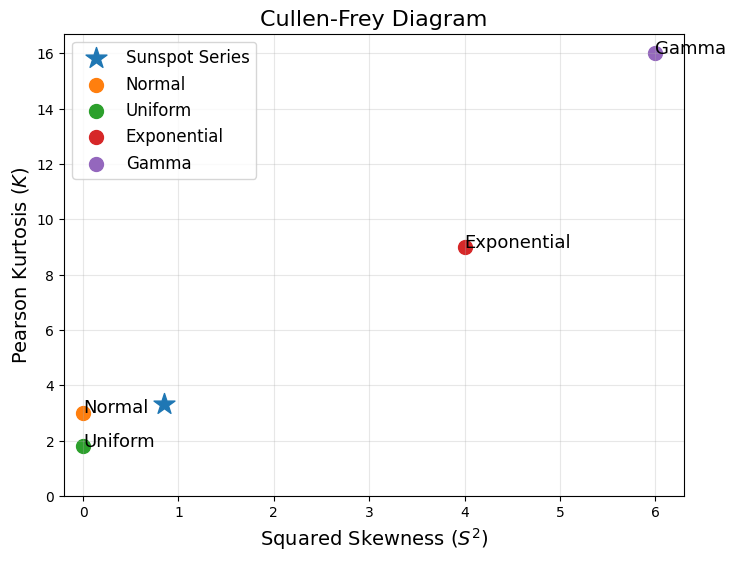

In [ ]:
# ============================================================
# Cullen-Frey Graph
# (Pearson Kurtosis vs Squared Skewness)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

# ------------------------------------------------------------
# Moments
# ------------------------------------------------------------

S = skew(x)
S2 = S**2

K = kurtosis(x, fisher=False)   # Pearson kurtosis

# ------------------------------------------------------------
# Reference distributions
# ------------------------------------------------------------

normal_x = 0
normal_y = 3

uniform_x = 0
uniform_y = 1.8

exponential_x = 4
exponential_y = 9

gamma_x = 6
gamma_y = 16

# ------------------------------------------------------------
# Distance from Gaussian point
# ------------------------------------------------------------

distance = np.sqrt((S2-0)**2 + (K-3)**2)

print("================================")
print("Cullen-Frey Coordinates")
print("================================")

print(f"Skewness              = {S:.4f}")
print(f"Squared Skewness      = {S2:.4f}")
print(f"Pearson Kurtosis      = {K:.4f}")

print(f"\nDistance from Normal Distribution = {distance:.4f}")

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(8,6))

# Data point
plt.scatter(S2,
            K,
            s=250,
            marker='*',
            label='Sunspot Series')

# Reference distributions
plt.scatter(normal_x, normal_y,
            s=100,
            label='Normal')

plt.scatter(uniform_x, uniform_y,
            s=100,
            label='Uniform')

plt.scatter(exponential_x, exponential_y,
            s=100,
            label='Exponential')

plt.scatter(gamma_x, gamma_y,
            s=100,
            label='Gamma')

# Labels
plt.annotate('Normal', (normal_x, normal_y), fontsize=13)
plt.annotate('Uniform', (uniform_x, uniform_y), fontsize=13)
plt.annotate('Exponential', (exponential_x, exponential_y), fontsize=13)
plt.annotate('Gamma', (gamma_x, gamma_y), fontsize=13)



plt.xlabel(r'Squared Skewness ($S^2$)', fontsize=14)
plt.ylabel(r'Pearson Kurtosis ($K$)', fontsize=14)

plt.title('Cullen-Frey Diagram', fontsize=16)

plt.grid(alpha=0.3)
plt.legend(fontsize=12)

plt.xlim(left=-0.2)
plt.ylim(bottom=0)

plt.show()

Lognormal Distribution Fit
Shape (σ) = 1.2252
Location  = 0.0000
Scale     = 51.2097


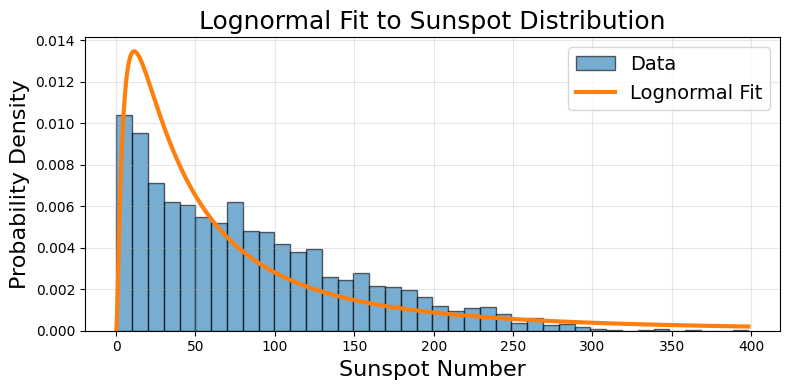

In [ ]:
# ============================================================
# Lognormal Distribution Fit
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

# ------------------------------------------------------------
# Remove zeros
# ------------------------------------------------------------

x_positive = x[x > 0]

# ------------------------------------------------------------
# Fit Lognormal
# ------------------------------------------------------------

shape, loc, scale = lognorm.fit(
    x_positive,
    floc=0
)

print("================================")
print("Lognormal Distribution Fit")
print("================================")

print(f"Shape (σ) = {shape:.4f}")
print(f"Location  = {loc:.4f}")
print(f"Scale     = {scale:.4f}")

# ------------------------------------------------------------
# Histogram
# ------------------------------------------------------------

plt.figure(figsize=(8,4))

plt.hist(
    x_positive,
    bins=40,
    density=True,
    alpha=0.6,
    edgecolor='black',
    label='Data'
)

# ------------------------------------------------------------
# Lognormal PDF
# ------------------------------------------------------------

xx = np.linspace(
    np.min(x_positive),
    np.max(x_positive),
    2000
)

pdf_ln = lognorm.pdf(
    xx,
    shape,
    loc=loc,
    scale=scale
)

plt.plot(
    xx,
    pdf_ln,
    linewidth=3,
    label='Lognormal Fit'
)

plt.xlabel('Sunspot Number', fontsize=16)
plt.ylabel('Probability Density', fontsize=16)

plt.title('Lognormal Fit to Sunspot Distribution',
          fontsize=18)

plt.legend(fontsize=14)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import kstest

D, pvalue = kstest(
    x_positive,
    'lognorm',
    args=(shape, loc, scale)
)

print("\nKolmogorov-Smirnov Test")
print("-----------------------")
print(f"D statistic = {D:.5f}")
print(f"p-value     = {pvalue:.5e}")


Kolmogorov-Smirnov Test
-----------------------
D statistic = 0.10745
p-value     = 1.77715e-32


Weibull Distribution Fit
Shape (k) = 1.1395
Location  = 0.0000
Scale (λ) = 87.5353


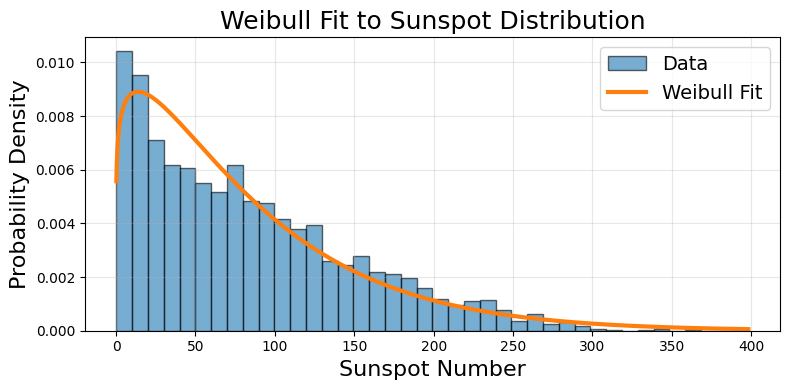

In [ ]:
# ============================================================
# Weibull Distribution Fit
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import weibull_min

# ------------------------------------------------------------
# Remove zeros
# ------------------------------------------------------------

x_positive = x[x > 0]

# ------------------------------------------------------------
# Fit Weibull
# ------------------------------------------------------------

shape, loc, scale = weibull_min.fit(
    x_positive,
    floc=0
)

print("================================")
print("Weibull Distribution Fit")
print("================================")

print(f"Shape (k) = {shape:.4f}")
print(f"Location  = {loc:.4f}")
print(f"Scale (λ) = {scale:.4f}")

# ------------------------------------------------------------
# Histogram
# ------------------------------------------------------------

plt.figure(figsize=(8,4))

plt.hist(
    x_positive,
    bins=40,
    density=True,
    alpha=0.6,
    edgecolor='black',
    label='Data'
)

# ------------------------------------------------------------
# Weibull PDF
# ------------------------------------------------------------

xx = np.linspace(
    np.min(x_positive),
    np.max(x_positive),
    2000
)

pdf_weibull = weibull_min.pdf(
    xx,
    shape,
    loc=loc,
    scale=scale
)

plt.plot(
    xx,
    pdf_weibull,
    linewidth=3,
    label='Weibull Fit'
)

plt.xlabel('Sunspot Number', fontsize=16)
plt.ylabel('Probability Density', fontsize=16)

plt.title('Weibull Fit to Sunspot Distribution',
          fontsize=18)

plt.legend(fontsize=14)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# KS Test for Weibull
# ============================================================

from scipy.stats import kstest

D, pvalue = kstest(
    x_positive,
    'weibull_min',
    args=(shape, loc, scale)
)

print("\nKolmogorov-Smirnov Test")
print("-----------------------")
print(f"D statistic = {D:.5f}")
print(f"p-value     = {pvalue:.5e}")


Kolmogorov-Smirnov Test
-----------------------
D statistic = 0.04404
p-value     = 8.33936e-06


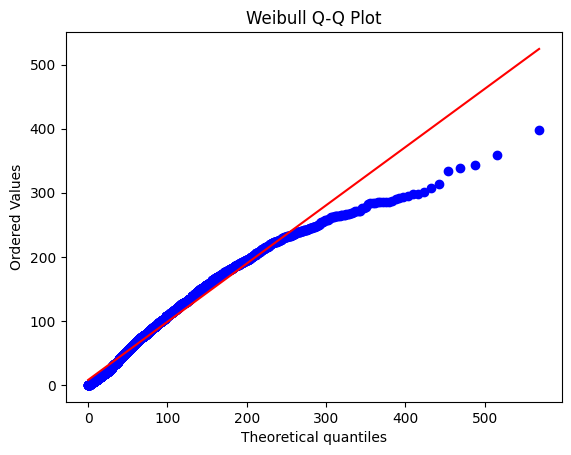

In [ ]:
from scipy.stats import weibull_min
import scipy.stats as stats

stats.probplot(
    x_positive,
    dist=weibull_min(shape, loc=0, scale=scale),
    plot=plt
)

plt.title('Weibull Q-Q Plot')
plt.show()

Spectral Analysis
Spectral Index β = 0.885
R²               = 0.584


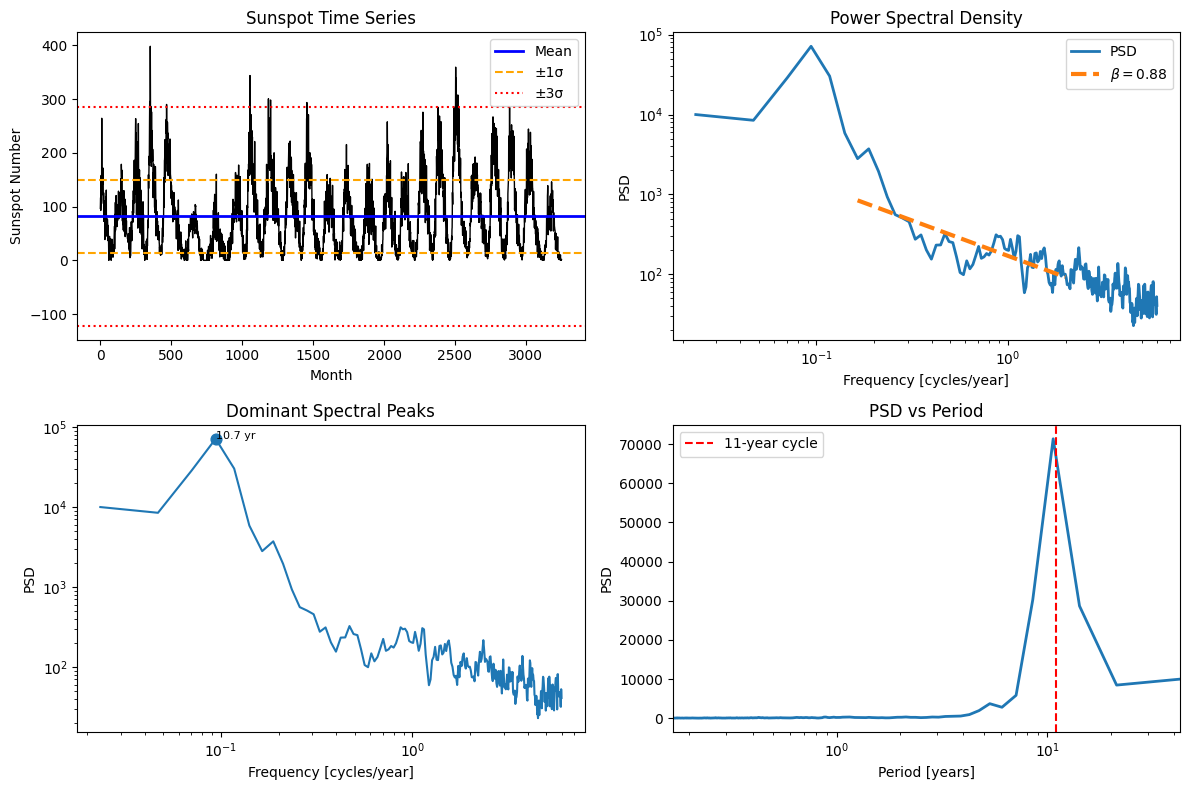

In [ ]:
# ============================================================
# Spectral Analysis of Sunspot Time Series
#
# Outputs:
#   A) Time Series
#   B) PSD + Power-Law Fit
#   C) PSD with Dominant Peaks
#   D) PSD versus Period
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import welch
from scipy.signal import find_peaks
from scipy.stats import linregress

# ------------------------------------------------------------
# Data
# ------------------------------------------------------------

signal = np.array(sunspots)

# remove mean
signal_detrended = signal - np.mean(signal)

# ------------------------------------------------------------
# PSD (Welch)
# ------------------------------------------------------------

freqs, psd = welch(
    signal_detrended,
    fs=12.0,             # monthly data -> frequency in cycles/year
    nperseg=512,
    scaling='density'
)

# remove f=0
freqs = freqs[1:]
psd = psd[1:]

# ------------------------------------------------------------
# Spectral Index Beta
# ------------------------------------------------------------

mask = (
    (freqs > 0.15) &
    (freqs < 2.0)
)

logf = np.log10(freqs[mask])
logpsd = np.log10(psd[mask])

slope, intercept, r_value, p_value, stderr = linregress(
    logf,
    logpsd
)

beta = -slope

print("================================")
print("Spectral Analysis")
print("================================")
print(f"Spectral Index β = {beta:.3f}")
print(f"R²               = {r_value**2:.3f}")

# ------------------------------------------------------------
# Peaks
# ------------------------------------------------------------

peaks, _ = find_peaks(
    psd,
    prominence=np.max(psd)*0.05
)

peak_freqs = freqs[peaks]

peak_periods = 1 / peak_freqs

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig = plt.figure(
    figsize=(12,8)
)

# ============================================================
# A) TIME SERIES
# ============================================================

ax1 = plt.subplot(221)

mean = np.mean(signal)
std = np.std(signal)

ax1.plot(signal,
         color='black',
         lw=1)

ax1.axhline(mean,
            color='blue',
            lw=2,
            label='Mean')

ax1.axhline(mean+std,
            color='orange',
            ls='--')

ax1.axhline(mean-std,
            color='orange',
            ls='--',
            label='±1σ')

ax1.axhline(mean+3*std,
            color='red',
            ls=':')

ax1.axhline(mean-3*std,
            color='red',
            ls=':',
            label='±3σ')

ax1.set_title('Sunspot Time Series')
ax1.set_xlabel('Month')
ax1.set_ylabel('Sunspot Number')
ax1.legend()

# ============================================================
# B) PSD + BETA
# ============================================================

ax2 = plt.subplot(222)

ax2.loglog(
    freqs,
    psd,
    lw=2,
    label='PSD'
)

ax2.loglog(
    freqs[mask],
    10**intercept * freqs[mask]**slope,
    '--',
    lw=3,
    label=fr'$\beta={beta:.2f}$'
)

ax2.set_title('Power Spectral Density')
ax2.set_xlabel('Frequency [cycles/year]')
ax2.set_ylabel('PSD')
ax2.legend()

# ============================================================
# C) PEAKS
# ============================================================

ax3 = plt.subplot(223)

ax3.loglog(freqs,
           psd)

ax3.scatter(
    peak_freqs,
    psd[peaks],
    s=60
)

for f, p in zip(peak_freqs, peak_periods):

    if p > 1:

        ax3.annotate(
            f'{p:.1f} yr',
            (f, psd[peaks][list(peak_freqs).index(f)]),
            fontsize=8
        )

ax3.set_title('Dominant Spectral Peaks')
ax3.set_xlabel('Frequency [cycles/year]')
ax3.set_ylabel('PSD')

# ============================================================
# D) PERIOD DOMAIN
# ============================================================

ax4 = plt.subplot(224)

periods = 1 / freqs

ax4.semilogx(
    periods,
    psd,
    lw=2
)

ax4.axvline(
    11,
    color='red',
    ls='--',
    label='11-year cycle'
)

ax4.set_xlim(
    periods.min(),
    periods.max()
)

ax4.set_title('PSD vs Period')
ax4.set_xlabel('Period [years]')
ax4.set_ylabel('PSD')

ax4.legend()

plt.tight_layout()
plt.show()

## **Interpretation: The statistical fluctuations of the sunspot number are markedly non-Gaussian, exhibiting positive skewness and heavy tails. Spectral analysis reveals a power-law background with spectral index β ≈ 0.8, indicating long-range temporal correlations and memory effects. Together, these results suggest that sunspot production is governed by a nonlinear, multiscale dynamical process rather than by a purely stochastic Gaussian mechanism. The observed behavior is consistent with intermittent magnetic activity generated by the solar dynamo operating far from equilibrium.**

#  I will provide a course booklet for review and hands-on practice!!   

  Thank you, see you next...